演習問題 3.4 c) -- 標準ベイズ統計学

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from scipy.stats import beta

In [2]:
# 1. データの準備 (theta の値を 0 ~ 1 までの 500 分割)
theta = np.linspace(0, 1, 500)

In [3]:
# 2. 各事前分布の確率密度 (PDF) を計算
# a) Beta(2, 8)
p_a = beta.pdf(theta, 2, 8)

# b) Beta(8, 2)
p_b = beta.pdf(theta, 8, 2)

# c) 混合事前分布 (Beta(2, 8) が 75%, Beta(8, 2) が 25%)
P_C = 0.75 * p_a + 0.25 * p_b

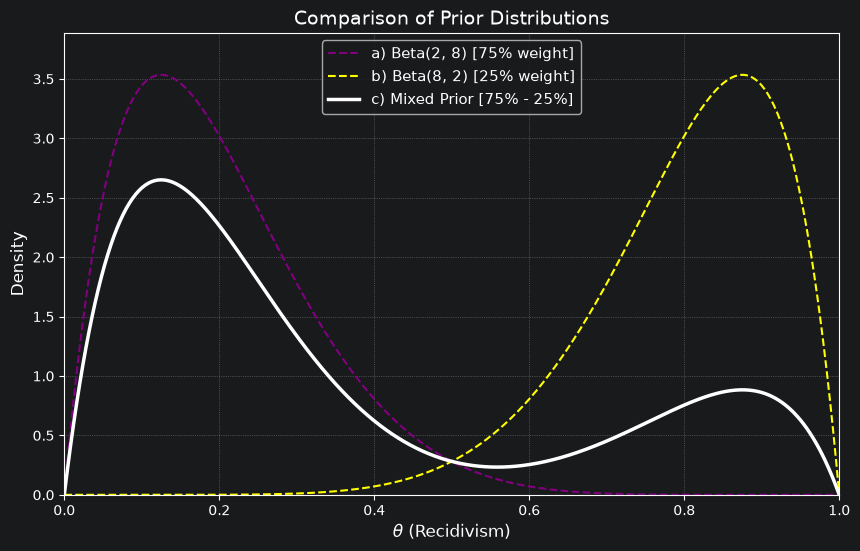

In [4]:
# グラフの描画
plt.figure(figsize=(10, 6))

# 各分布のプロット
plt.plot(theta, p_a, label="a) Beta(2, 8) [75% weight]", color="purple", linestyle="--")
plt.plot(theta, p_b, label="b) Beta(8, 2) [25% weight]", color="yellow", linestyle="--")
plt.plot(theta, P_C, label="c) Mixed Prior [75% - 25%]", color="white", linewidth=2.5)

# グラフの装飾
plt.title("Comparison of Prior Distributions", fontsize=14)
plt.xlabel(r"$\theta$ (Recidivism)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, max(p_a) * 1.1) # Y軸の範囲を少し広めに設定
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

plt.show()

# 3.1 二項モデル
ex). 二項分布と一様分布

In [1]:
from scipy.stats import beta

# 事前分布のパラメタ
a = 1
b = 1  # 事前分布

# Data の入力
n = 10
y = 2  # Data

# ベータ分布の累積分布関数の逆関数(ppf)を使って、下端 (2.5% 点) と上端 (97.5% 点) を計算
lower = beta.ppf(0.025, a + y, b + n -y)
upper = beta.ppf(0.975, a + y, b + n -y)

print(f"{lower:.8f}, {upper:.8f}")

0.06021773, 0.51775585


## 3.2.2 出生率

In [3]:
import pymc as pm
import arviz as az
import numpy as np

In [4]:
# 1. 事前分布のパラメータ (Gamma分布)
alpha_prior = 2
beta_prior = 1

# 2. 各グループのデータ
# Group01: n=111, sum_y=217 / Group02: n=44, sum_y=66
sizes_sample = np.array([111, 44])
sum_events = np.array([217, 66])

#3. PyMC Model の構築 (２つのグループをまとめてベクトル処理)
with pm.Model() as model:
    # 形状(shape=2) を指定して、Group01/02 の Parameter: λ を同時に定義
    # ※ PyMC の Gamma では R の rate(b) を beta と呼びます
    lambda_param = pm.Gamma("lambda", alpha=alpha_prior, beta=beta_prior, shape=2)

    # Poisson分布の観測モデル
    # 各グループのデータ (合計) は Poisson(n * lambda) に従います
    y_obs = pm.Poisson("y_obs", mu=sizes_sample * lambda_param, observed=sum_events)

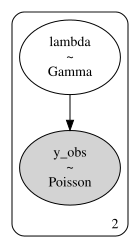

In [5]:
pm.model_to_graphviz(model)

In [6]:
# MCMC Sampling の実行
# ※再現性のために random_seed を固定
with model:
    idata = pm.sample(draws=3000, tune=1000, random_seed=42, nuts_sampler="numpyro")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


In [10]:
# --- 4. 事後統計量の算出と出力 ---
# MCMC Sampling (次元: [chain, draw, group]) を取得して１次元/２次元配列にまとめる
samples_lambda = idata.posterior["lambda"].to_numpy().reshape(-1, 2)

for i, name_group in enumerate(["グループ 1", "グループ 2"]):
    samples = samples_lambda[:, i]

    # (A) 事後平均 (Posterior Mean)
    mean_posterior = np.mean(samples)

    # (B) 事後Mode (Posterior Mode / MAP推定量)
    # 連続分布の MCMC サンプルからモードを求めるため、カーネル密度推定 (KDE) を使用
    grid, pdf = az.kde(samples)
    mode_posterior = grid[np.argmax(pdf)]

    # (C) 95% 信用区間 (Equal-Tailed Interval: 2.5% ~ 97.5%)
    # ※ R の qgamma と合わせるためのパーセンタイル区間を算出
    credible_interval_95 = np.percentile(samples, [2.5, 97.5])

    print(f"--- {name_group} ---")
    print(f"事後平均 : {mean_posterior:.6f}")
    print(f"事後モード : {mode_posterior:.6f}")
    print(f"95% 信用区間: {credible_interval_95[0]:.6f}")

--- グループ 1 ---
事後平均 : 1.953155
事後モード : 1.960484
95% 信用区間: 1.704892
--- グループ 2 ---
事後平均 : 1.511199
事後モード : 1.524456
95% 信用区間: 1.169337
